In [2]:
import numpy as np 
import astropy.units as u
from astropy.constants import astropyconst20 as const
import matplotlib.pyplot as plt

# Question 1b

In [3]:
gamma = 2 * const.e / (const.m_e)

In [4]:
B = [0.5, 100, 5000] * u.G 
mag_field_names = ["Earth's magnetic field", "air-cooled wire", "strong permanent magnet"]

In [5]:
(gamma * B).decompose()

<Quantity [1.75882002e+07, 3.51764005e+09, 1.75882002e+11] 1 / s>

In [6]:
E = gamma * B * const.hbar/2

In [7]:
freqs = E.to(u.J)/(const.h)
temps = E.to(u.J)/(const.k_B)

In [8]:
print("Magnetic Field | Frequency [Hz] | Temperature [K]")
print("-" * 60)
for name, freq, temp in zip(mag_field_names, freqs, temps):
    print(f"{name:<25} | {freq.to(u.Hz).value:>14.2e} | {temp.value:>14.2e}")

Magnetic Field | Frequency [Hz] | Temperature [K]
------------------------------------------------------------
Earth's magnetic field    |       1.40e+06 |       6.72e-05
air-cooled wire           |       2.80e+08 |       1.34e-02
strong permanent magnet   |       1.40e+10 |       6.72e-01


# Question 1d

### (i) $\vec B \parallel \hat z$

$H = \Delta S_z^2 - \gamma S_zB_z$
work in freq units so 
$H = (\Delta/h)S_z^2 - \gamma/h S_zB_z$

In [9]:
gamma1 = -2.8e-3 #GHz 
Delta = 2.87 #GHz

In [10]:
B = np.linspace(0, 1050, 100) 

E1 = Delta - gamma1 * B 
E0 = Delta*np.ones_like(B)
E_1 = Delta + gamma1 * B

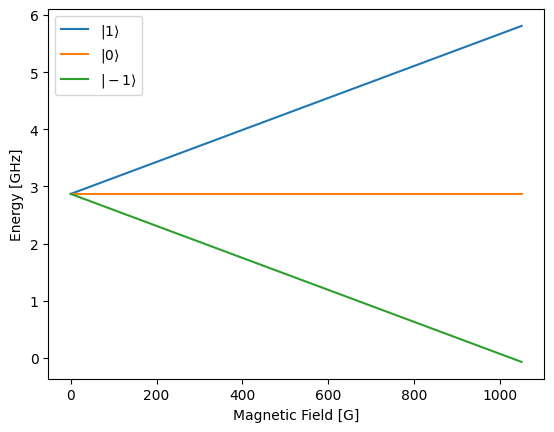

In [11]:
plt.plot(B, E1, label=(rf'$|1 \rangle$'))
plt.plot(B, E0, label=(rf'$|0 \rangle$'))
plt.plot(B, E_1, label=(rf'$|-1 \rangle$'))
plt.xlabel("Magnetic Field [G]")
plt.ylabel("Energy [GHz]")
plt.legend()

### (ii) $\vec B \perp \hat z$

In [12]:
disc = np.sqrt(4 * B**2 * gamma1**2 + Delta**2)

E_Bperp_0 = Delta * np.ones_like(B)
E_Bperp_1 = (Delta - disc)/2 
E_Bperp_2 = (Delta + disc)/2

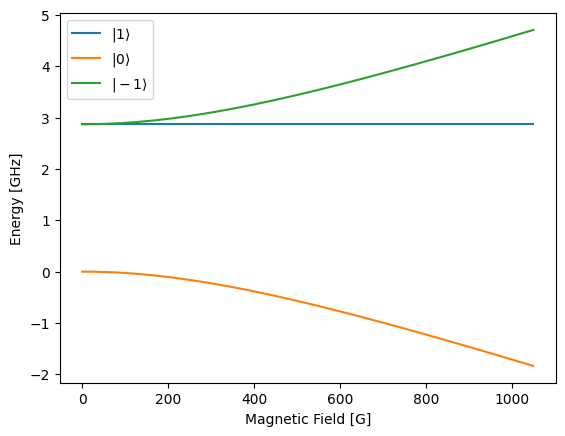

In [13]:
plt.plot(B, E_Bperp_0, label=(rf'$|1 \rangle$'))
plt.plot(B, E_Bperp_1, label=(rf'$|0 \rangle$'))
plt.plot(B, E_Bperp_2, label=(rf'$|-1 \rangle$'))
plt.xlabel("Magnetic Field [G]")
plt.ylabel("Energy [GHz]")
plt.legend()

# Question 2

In [14]:
import scipy.integrate as scpint

In [15]:
def exp_decay(t, y): return -0.5 * y
sol = scpint.solve_ivp(exp_decay, [0, 10], [0, 1])

In [16]:
sol.y[1]

array([1.        , 0.94028757, 0.50802462, 0.19465976, 0.0763307 ,
       0.02986809, 0.01167174, 0.00676025])

In [17]:
def rotating_frame_system(t, y, delta, omega, nu):
    # y = [alphaRe, alphaIm, betaRe, betaIm]
    omega_sin = (np.sin(2 * nu * t)) * omega
    omega_cos = (1 + np.cos(2 * nu * t)) * omega

    mat = 1/2 * np.array([
        [0, -delta, omega_sin, -omega_cos],
        [delta, 0, omega_cos, omega_sin],
        [omega_sin, -omega_cos, 0, delta],
        [omega_cos, omega_sin, -delta, 0]
        ])

    return mat @ y


def rwa(t, delta, omega):
    omegaR = np.sqrt(delta**2 + omega**2)
    alphaRe = np.cos(1/2 * t * omegaR)
    alphaIm = delta/omegaR * np.sin(1/2 * t * omegaR)
    betaRe = 0 * np.ones_like(t)
    betaIm = omega/omegaR * np.sin(1/2 * t * omegaR)

    return [alphaRe, alphaIm, betaRe, betaIm]


In [31]:
from matplotlib.lines import Line2D


def visualize_overlap(delta, Omega, nu, t0, tf):
    tspace = np.linspace(t0, tf, 500)
    sol = scpint.solve_ivp(rotating_frame_system, args=[delta, Omega, nu], t_span=[t0, tf], y0=[1, 0, 0, 0], t_eval=tspace)
    approx = rwa(tspace, delta, Omega)

    fig, axes = plt.subplots(3, 2, figsize=(14, 10), sharex=True)
    labels = [
        r"$\mathrm{Re[\alpha]}$",
        r"$\mathrm{Im[\alpha]}$",
        r"$\mathrm{Re[\beta]}$",
        r"$\mathrm{Im[\beta]}$",
    ]

    for ax, idx, label in zip(axes.flat, range(4), labels):
        ax.plot(tspace, sol.y[idx], lw=2, label="numerical")
        ax.plot(tspace, approx[idx], "--", lw=2, label="RWA")
        ax.set_title(f"{label}")
        ax.set_xlabel("t")
        ax.grid(alpha=0.3)

    alpha_prob_num = np.sqrt(sol.y[0]**2 + sol.y[1]**2)
    alpha_prob_rwa = np.sqrt(approx[0]**2 + approx[1]**2)

    beta_prob_num = np.sqrt(sol.y[2]**2 + sol.y[3]**2)
    beta_prob_rwa = np.sqrt(approx[2]**2 + approx[3]**2)

    axes.flat[4].plot(tspace, alpha_prob_num, lw=2, label="numerical")
    axes.flat[4].plot(tspace, alpha_prob_rwa, "--", lw=2, label="RWA")
    axes.flat[4].set_title(r"$|\alpha|^2$")
    axes.flat[4].set_xlabel("t")
    axes.flat[4].grid(alpha=0.3)

    axes.flat[5].plot(tspace, beta_prob_num, lw=2, label="numerical")
    axes.flat[5].plot(tspace, beta_prob_rwa, "--", lw=2, label="RWA")
    axes.flat[5].set_title(r"$|\beta|^2$")
    axes.flat[5].set_xlabel("t")
    axes.flat[5].grid(alpha=0.3)

    legend_handles = [
        Line2D([0], [0], color="C0", lw=2, label="numerical"),
        Line2D([0], [0], color="C0", lw=2, ls="--", label="RWA"),
    ]

    fig.legend(
        handles=legend_handles,
        loc="upper center",
        bbox_to_anchor=(0.5, 0.95),
        ncol=2
    )

    fig.suptitle(rf"$\delta$ = {delta}, $\Omega$ = {Omega}, $\nu$ = {nu}", fontsize=20)
    fig.tight_layout(rect=[0, 0, 1, 0.97])
    plt.show()


def visualize_residual(delta, Omega, nu, t0, tf):
    tspace = np.linspace(t0, tf, 500)
    sol = scpint.solve_ivp(rotating_frame_system, args=[delta, Omega, nu], t_span=[t0, tf], y0=[1, 0, 0, 0], t_eval=tspace)
    approx = rwa(tspace, delta, Omega)

    fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharex=True)
    labels = [
        r"$\mathrm{Re[\alpha]}$",
        r"$\mathrm{Im[\alpha]}$",
        r"$\mathrm{Re[\beta]}$",
        r"$\mathrm{Im[\beta]}$",
    ]

    for ax, idx, label in zip(axes.flat, range(4), labels):
        residual = sol.y[idx] - approx[idx]
        ax.plot(tspace, residual, lw=2)
        ax.set_title(f"{label}")
        ax.set_xlabel("t")
        ax.grid(alpha=0.3)

    fig.suptitle(rf"$\delta$ = {delta}, $\Omega$ = {Omega}, $\nu$ = {nu}", fontsize=20)
    fig.tight_layout(rect=[0, 0, 1, 0.97])    
    plt.show()



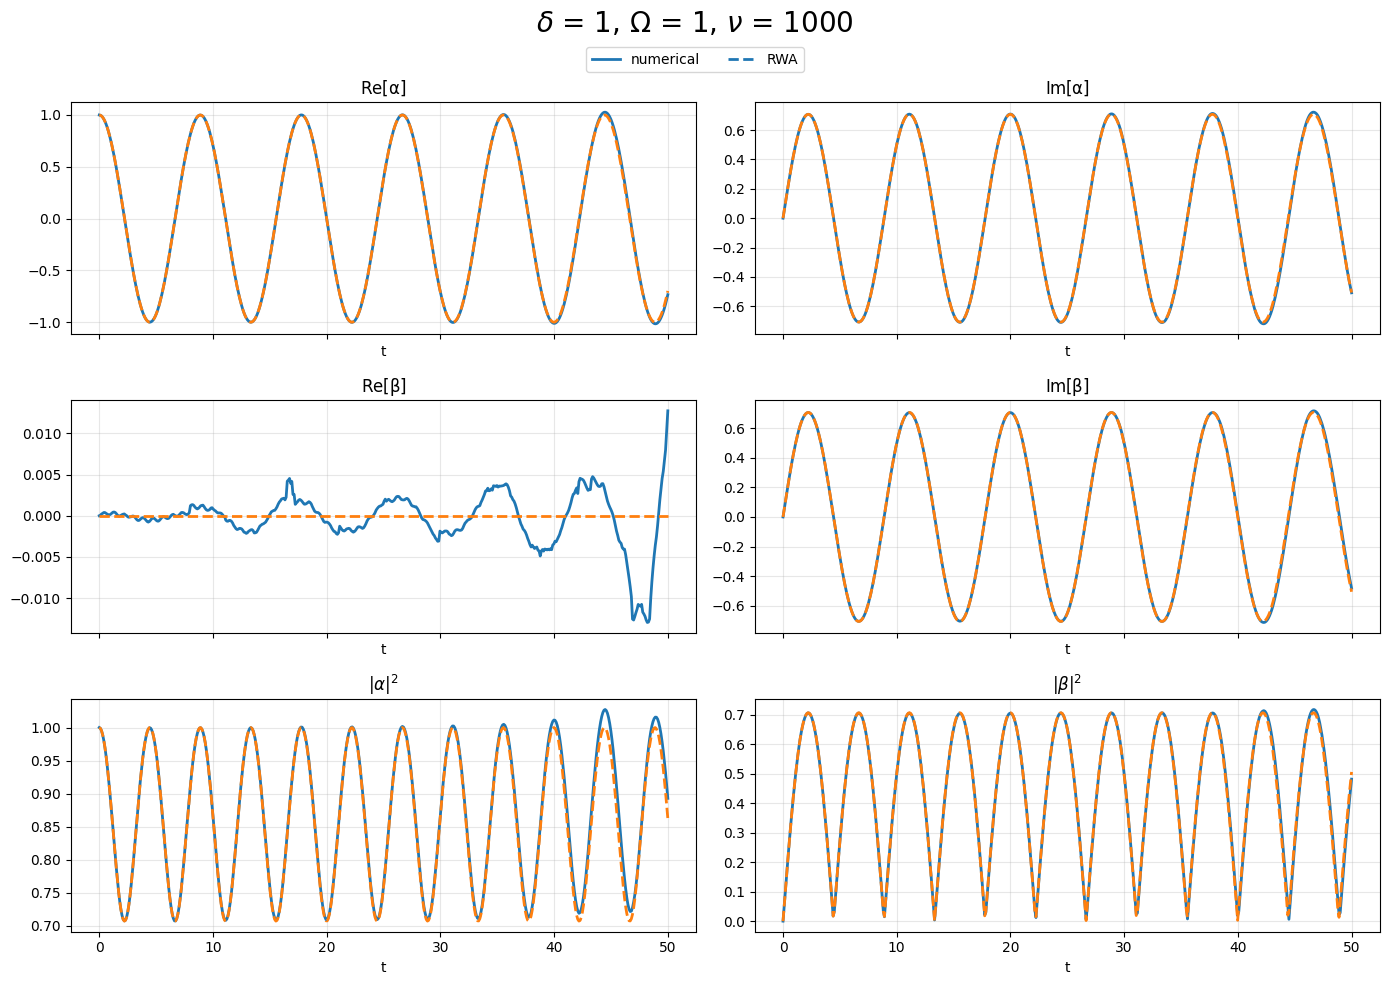

In [50]:
visualize_overlap(delta=1, Omega=1, nu=1000, t0=0, tf=50)

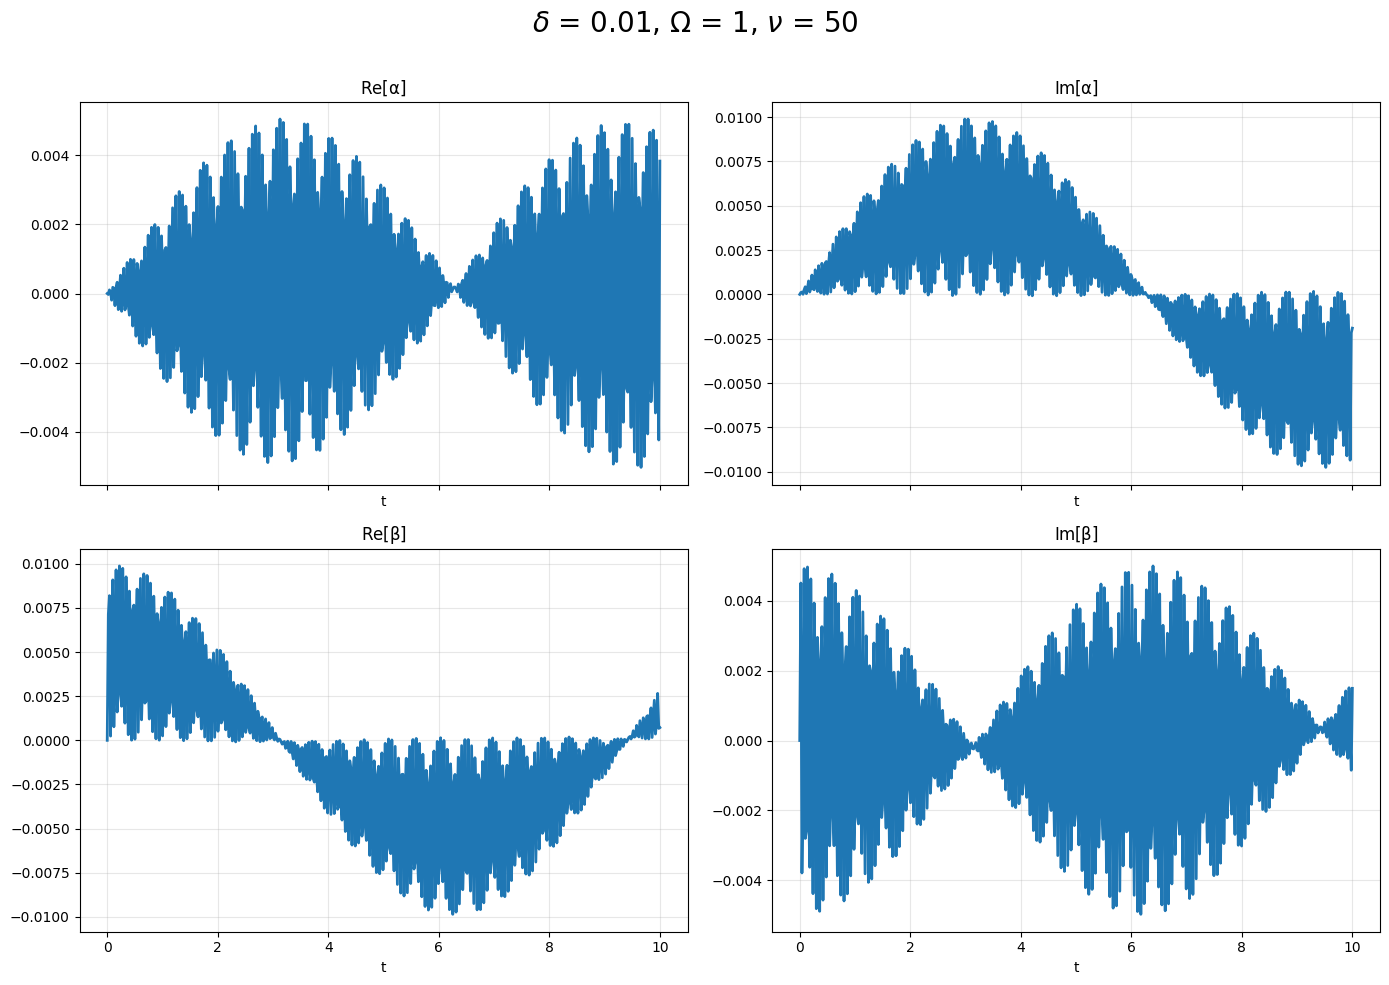

In [51]:
visualize_residual(delta=0.01, Omega=1, nu=50, t0=0, tf=10)

In [44]:
np.pi/(2 * 50)

0.031415926535897934

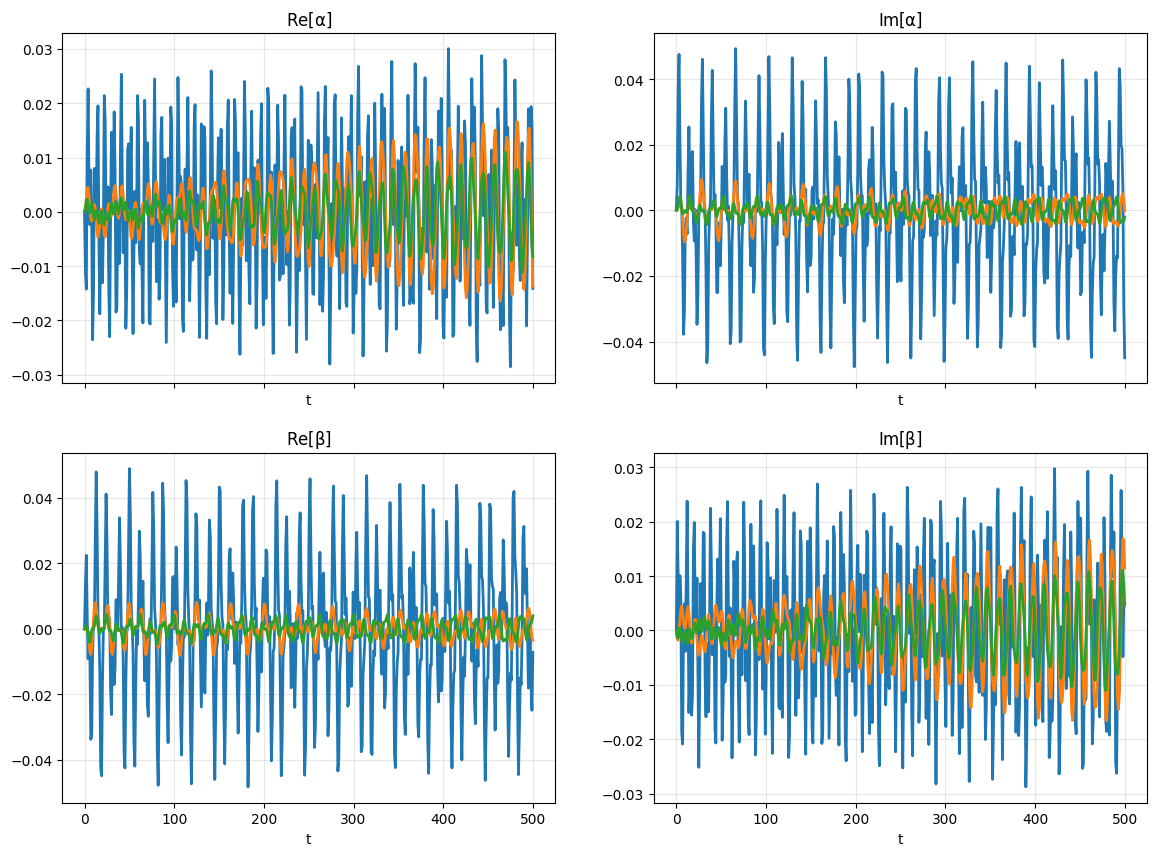

In [25]:
def visualize_nu(delta, Omega, t0, tf, nu_values):
    tspace = np.linspace(t0, tf, 500)
    approx = rwa(tspace, delta, Omega)
    fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharex=True)
    labels = [
            r"$\mathrm{Re[\alpha]}$",
            r"$\mathrm{Im[\alpha]}$",
            r"$\mathrm{Re[\beta]}$",
            r"$\mathrm{Im[\beta]}$",
    ]

    for nu in nu_values:
        sol = scpint.solve_ivp(rotating_frame_system, args=[delta, Omega, nu], t_span=[t0, tf], y0=[1, 0, 0, 0], t_eval=tspace)

        for ax, idx, label in zip(axes.flat, range(4), labels):
            residual = sol.y[idx] - approx[idx]
            ax.plot(tspace, residual, lw=2)
            ax.set_title(f"{label}")
            ax.set_xlabel("t")
            ax.grid(alpha=0.3)

    plt.show()


visualize_nu(delta=0.01, Omega=1, t0=0, tf=500, nu_values=[10, 50, 100])

# Questions

2d numerical instability for large nu? 

2d 